<a href="https://colab.research.google.com/github/Rrg331/FPNSi/blob/main/FPNSi_PPGI_Experimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento — Benchmark de LLMs na geração de modelos de processo (BPMN)
### Integração de instalações de geração ao SIN — Submódulo 7.13 dos Procedimentos de Rede do ONS

Este notebook executa, **ao vivo**, a comparação de três LLMs na tarefa de modelar em **BPMN** o processo de
emissão de declaração de atendimento aos Procedimentos de Rede (Submódulo 7.13). Os modelos avaliados são:

| Sigla | Modelo | Provedor |
|---|---|---|
| Sonnet 4.6 | `anthropic.claude-sonnet-4-6` | AWS Bedrock |
| Haiku 4.5 | `anthropic.claude-haiku-4-5` | AWS Bedrock |
| Llama | `llama-3.3-70b-versatile` (ajustável) | Groq |

**Fluxo:** carregar credenciais → carregar o texto do 7.13 → enviar o mesmo prompt às 3 LLMs (temperatura fixa) →
avaliar cada saída contra o modelo de referência (*ground truth*) → calcular métricas (TCR, TRO, TEE, P, R, F1) →
gerar tabelas e gráficos para o artigo.

> As credenciais usam o mesmo nome de variável localmente .env e no Google Colab (Secrets). Veja a célula de credenciais.


## 1. Dependências

In [ ]:
%pip install -q "anthropic[bedrock]" groq pandas matplotlib python-dotenv

Note: you may need to restart the kernel to use updated packages.


## 2. Credenciais (compatível com `.env` local e Colab Secrets)

Cadastre, com **os mesmos nomes**, em um arquivo `.env` (local) ou em *Secrets* do Colab:
`AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, `AWS_REGION`, `GROQ_API_KEY`.

In [ ]:
import os, json, time, re
from pathlib import Path

# .env local (ignorado silenciosamente no Colab)
try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True))
except Exception:
    pass

def get_secret(name: str):
    """Busca um segredo: 1) Colab Secrets; 2) variavel de ambiente / .env."""
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v:
            return v
    except Exception:
        pass
    return os.environ.get(name)

AWS_ACCESS_KEY_ID     = get_secret("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = get_secret("AWS_SECRET_ACCESS_KEY")
AWS_SESSION_TOKEN     = get_secret("AWS_SESSION_TOKEN")  # opcional
AWS_REGION            = get_secret("AWS_REGION") or "us-east-1"
GROQ_API_KEY          = get_secret("GROQ_API_KEY")

faltando = [k for k, v in {
    "AWS_ACCESS_KEY_ID": AWS_ACCESS_KEY_ID,
    "AWS_SECRET_ACCESS_KEY": AWS_SECRET_ACCESS_KEY,
    "GROQ_API_KEY": GROQ_API_KEY,
}.items() if not v]
if faltando:
    print("ATENCAO: credenciais ausentes ->", faltando)
    print("Cadastre no .env (local) ou em Secrets (Colab) antes de rodar as chamadas ao vivo.")
else:
    print("Credenciais carregadas. Regiao AWS:", AWS_REGION)

Credenciais carregadas. Regiao AWS: us-east-1


## 3. Configuração dos modelos e parâmetros do experimento

A temperatura é fixada em 0 para favorecer a reprodutibilidade e avaliar o desempenho de primeira resposta
(sem refinamento iterativo). Os IDs do Bedrock podem exigir *inference profile* regional (`us.anthropic...`)
conforme a conta — há *fallback* automático.

In [ ]:
TEMPERATURE     = 0.0
MAX_TOKENS      = 16000  # Bedrock (Sonnet/Haiku). Com 8000 as saidas foram truncadas (stop_reason=max_tokens)
MAX_TOKENS_GROQ = 3500   # Groq free tier: limite de 12k tokens/min cobre entrada + saida (Llama concluiu naturalmente bem abaixo do teto)

GROQ_LLAMA_MODEL = "llama-3.3-70b-versatile"  # ajuste para a versao de Llama disponivel na sua conta Groq

# IDs sao inference profiles regionais (prefixo us.), exigidos pelos modelos 4.x
# no acesso on-demand do Bedrock. Confirmados na conta em 2026-06-09.
MODELOS = {
    "Sonnet 4.6": {"provider": "bedrock", "model_id": "us.anthropic.claude-sonnet-4-6"},
    "Haiku 4.5":  {"provider": "bedrock", "model_id": "us.anthropic.claude-haiku-4-5-20251001-v1:0"},
    "Llama":      {"provider": "groq",    "model_id": GROQ_LLAMA_MODEL},
}

# Modelo usado como AVALIADOR (juiz) do matching requisito-a-requisito.
# Usar Sonnet (mais capaz) como juiz; e uma ameaca a validade discutida no artigo.
JUIZ = {"provider": "bedrock", "model_id": "us.anthropic.claude-sonnet-4-6"}

SAIDAS_DIR = Path("dados/saidas"); SAIDAS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR    = Path("figuras");      FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Modelos:", list(MODELOS))

Modelos: ['Sonnet 4.6', 'Haiku 4.5', 'Llama']


## 4. Documento de entrada — texto do Submódulo 7.13 (versão condensada)

Para manter um **prompt idêntico** aos três modelos respeitando o limite de tokens por minuto do Groq
(free tier), usa-se uma versão condensada do Submódulo 7.13: removem-se cabeçalhos/rodapés de página e as
tabelas repetidas do ANEXO B para as modalidades Tipo II-A, II-B, II-C e III, preservando a tabela
representativa do Tipo I (38–41 requisitos) e toda a descrição do processo (DIR, DAPR/T, DAPR/P, DAPR/D),
do ANEXO A e dos fluxos de exceção. O texto integral permanece em `dados/submodulo_7_13.txt`.

In [ ]:
DOC_PATH = Path("dados/submodulo_7_13_curto.txt")
if not DOC_PATH.exists():
    DOC_PATH = Path("dados/submodulo_7_13.txt")  # fallback para o integral
if not DOC_PATH.exists():
    raise FileNotFoundError(
        "dados/submodulo_7_13*.txt nao encontrado. "
        "No Colab, faca upload da pasta 'dados/' (ou monte o Google Drive)."
    )
DOCUMENTO_7_13 = DOC_PATH.read_text(encoding="utf-8")
print("Documento carregado:", DOC_PATH.name, "|", len(DOCUMENTO_7_13), "caracteres")

Documento carregado: submodulo_7_13_curto.txt | 20423 caracteres


## 5. Prompt padronizado (idêntico para as 3 LLMs)

Estrutura conforme Arvidsson & Axell (2023): (a) papel/contexto, (b) tarefa, (c) documento, (d) formato de saída.
Este é o conteúdo do **Apêndice B** do artigo.

In [ ]:
SYSTEM_PROMPT = (
    "Voce e um analista especialista em Modelagem de Processos de Negocio (BPMN) atuando no setor "
    "eletrico brasileiro. Voce conhece os Procedimentos de Rede do ONS e modela processos normativos "
    "com rigor, identificando atores (raias), atividades, eventos, gateways de decisao e fluxos de excecao."
)

INSTRUCAO_TAREFA = (
    "Tarefa: a partir do documento normativo abaixo (Submodulo 7.13 dos Procedimentos de Rede do ONS), "
    "produza um MODELO DE PROCESSO DE NEGOCIO em notacao BPMN do processo de emissao das declaracoes de "
    "atendimento (DIR, DAPR/T, DAPR/P e DAPR/D) para integracao de instalacoes de geracao ao SIN.\n\n"
    "Entregue, em texto estruturado:\n"
    "1) RAIAS (pools/lanes): liste todos os atores envolvidos.\n"
    "2) ATIVIDADES: liste as atividades/tarefas do processo, na ordem, indicando o ator responsavel.\n"
    "3) GATEWAYS / DECISOES: pontos de decisao (ex.: existencia de pendencias impeditivas).\n"
    "4) EVENTOS: inicio, fim e eventos intermediarios relevantes.\n"
    "5) FLUXOS DE EXCECAO: caminhos alternativos (ex.: nao emissao, suspensao e reinicio, prazos).\n"
    "6) FLUXO DE SEQUENCIA: descreva a ordem das atividades e desvios.\n"
    "Seja completo e fiel ao documento. Nao invente etapas que nao constem do normativo."
)

def build_prompt(documento: str) -> str:
    return INSTRUCAO_TAREFA + "\n\n===== DOCUMENTO (Submodulo 7.13) =====\n" + documento

USER_PROMPT = build_prompt(DOCUMENTO_7_13)
print(USER_PROMPT[:600], "...")

Tarefa: a partir do documento normativo abaixo (Submodulo 7.13 dos Procedimentos de Rede do ONS), produza um MODELO DE PROCESSO DE NEGOCIO em notacao BPMN do processo de emissao das declaracoes de atendimento (DIR, DAPR/T, DAPR/P e DAPR/D) para integracao de instalacoes de geracao ao SIN.

Entregue, em texto estruturado:
1) RAIAS (pools/lanes): liste todos os atores envolvidos.
2) ATIVIDADES: liste as atividades/tarefas do processo, na ordem, indicando o ator responsavel.
3) GATEWAYS / DECISOES: pontos de decisao (ex.: existencia de pendencias impeditivas).
4) EVENTOS: inicio, fim e eventos in ...


## 6. Modelo de referência (*ground truth*)

Elicitado do texto do Submódulo 7.13 e da entrevista com o especialista de integração do ONS
(Vinicius Magalhães). Cada elemento tem uma categoria, usada nas métricas e na análise de omissões.

In [ ]:
GROUND_TRUTH = [
    # --- Atores / raias ---
    {"id": "A1", "categoria": "ator", "descricao": "Agente de Geracao"},
    {"id": "A2", "categoria": "ator", "descricao": "ONS"},
    {"id": "A3", "categoria": "ator", "descricao": "ANEEL"},
    {"id": "A4", "categoria": "ator", "descricao": "CCEE"},
    # --- Atividades / fluxo principal ---
    {"id": "P1",  "categoria": "atividade", "descricao": "Solicitacao de DIR pelo Agente de Geracao"},
    {"id": "P2",  "categoria": "atividade", "descricao": "Analise da solicitacao de DIR pelo ONS"},
    {"id": "P3",  "categoria": "atividade", "descricao": "Emissao da DIR"},
    {"id": "P4",  "categoria": "atividade", "descricao": "Solicitacao de DAPR/T pelo Agente de Geracao"},
    {"id": "P5",  "categoria": "atividade", "descricao": "Analise dos requisitos impeditivos para DAPR/T"},
    {"id": "P6",  "categoria": "atividade", "descricao": "Emissao da DAPR/T"},
    {"id": "P7",  "categoria": "atividade", "descricao": "Inicio da operacao em teste"},
    {"id": "P8",  "categoria": "atividade", "descricao": "Realizacao do teste de 96 horas"},
    {"id": "P9",  "categoria": "atividade", "descricao": "Solicitacao de DAPR/P pelo Agente de Geracao"},
    {"id": "P10", "categoria": "atividade", "descricao": "Analise da DAPR/P com pendencias nao impeditivas e prazos"},
    {"id": "P11", "categoria": "atividade", "descricao": "Emissao da DAPR/P"},
    {"id": "P12", "categoria": "atividade", "descricao": "Emissao direta da DAPR/D (sem pendencias)"},
    {"id": "P13", "categoria": "atividade", "descricao": "Solicitacao e analise de DAPR/D"},
    {"id": "P14", "categoria": "atividade", "descricao": "Emissao da DAPR/D"},
    # --- Fluxos de excecao ---
    {"id": "E1", "categoria": "fluxo_excecao", "descricao": "Pendencia impeditiva conduz a nao emissao da declaracao"},
    {"id": "E2", "categoria": "fluxo_excecao", "descricao": "Suspensao do processo e reinicio apos confirmacao da solucao e nova solicitacao"},
    {"id": "E3", "categoria": "fluxo_excecao", "descricao": "Pendencia nao impeditiva conduz a DAPR/P com prazo"},
    {"id": "E4", "categoria": "fluxo_excecao", "descricao": "Revalidacao de prazo pela ANEEL, ate duas vezes mediante justificativa"},
    {"id": "E5", "categoria": "fluxo_excecao", "descricao": "Comunicacao a ANEEL"},
    # --- Requisitos documentais/regulatorios ---
    {"id": "R1",  "categoria": "requisito", "descricao": "Conformidade com o Ato Autorizativo/outorga"},
    {"id": "R2",  "categoria": "requisito", "descricao": "Designacao de interlocutores"},
    {"id": "R3",  "categoria": "requisito", "descricao": "Parecer de Acesso (Rede Basica, ICG ou DIT) e atendimento a ressalvas/pendencias"},
    {"id": "R4",  "categoria": "requisito", "descricao": "Instrumento de garantia financeira e CUST com MUST vigente"},
    {"id": "R5",  "categoria": "requisito", "descricao": "Inexistencia de inadimplencia nos encargos de transmissao"},
    {"id": "R6",  "categoria": "requisito", "descricao": "CCT (Contrato de Conexao a Transmissao)"},
    {"id": "R7",  "categoria": "requisito", "descricao": "Diagrama unifilar (pre-operacional e operacional)"},
    {"id": "R8",  "categoria": "requisito", "descricao": "Medicao para faturamento: aprovacao do projeto e cadastro do ponto na CCEE"},
    {"id": "R9",  "categoria": "requisito", "descricao": "Telecomunicacao, supervisao e controle (canais de dados e voz, base de dados, teste ponto a ponto, SOE)"},
    {"id": "R10", "categoria": "requisito", "descricao": "Estudos pre-operacionais (Submodulo 7.4), comissionamento e validacao de modelos"},
    # --- Requisitos implicitos (entrevista) ---
    {"id": "I1", "categoria": "implicito", "descricao": "Fase de teste como etapa mais trabalhosa e geradora de pendencias"},
    {"id": "I2", "categoria": "implicito", "descricao": "Persistencia de pendencias por anos e risco sistemico (apagao de agosto de 2023)"},
    {"id": "I3", "categoria": "implicito", "descricao": "Distincao entre requisitos automatizaveis e os que demandam especialista humano"},
]
import pandas as pd
gt_df = pd.DataFrame(GROUND_TRUTH)
print("Elementos no ground truth:", len(GROUND_TRUTH))
gt_df["categoria"].value_counts()

Elementos no ground truth: 36


categoria
atividade        14
requisito        10
fluxo_excecao     5
ator              4
implicito         3
Name: count, dtype: int64

## 7. Clientes de API e função de chamada (ao vivo, com cache)

As saídas brutas são salvas em `dados/saidas/` para permitir recomputar as métricas sem repetir as chamadas.

In [ ]:
def _client_bedrock():
    from anthropic import AnthropicBedrock
    kwargs = dict(aws_region=AWS_REGION, aws_access_key=AWS_ACCESS_KEY_ID, aws_secret_key=AWS_SECRET_ACCESS_KEY)
    if AWS_SESSION_TOKEN:
        kwargs["aws_session_token"] = AWS_SESSION_TOKEN
    return AnthropicBedrock(**kwargs)

def _chamar_bedrock(model_id, system, user, temperature=TEMPERATURE, max_tokens=MAX_TOKENS):
    """Chamada via streaming (recomendado p/ saidas longas). Retorna (texto, stop_reason)."""
    client = _client_bedrock()
    tentativas = [model_id, "us." + model_id]  # fallback p/ inference profile regional
    ultimo_erro = None
    for mid in tentativas:
        try:
            with client.messages.stream(
                model=mid, max_tokens=max_tokens, temperature=temperature,
                system=system, messages=[{"role": "user", "content": user}],
            ) as stream:
                resp = stream.get_final_message()
            texto = "".join(b.text for b in resp.content if b.type == "text")
            return texto, resp.stop_reason
        except Exception as e:
            ultimo_erro = e
    raise ultimo_erro

def _chamar_groq(model_id, system, user, temperature=TEMPERATURE, max_tokens=MAX_TOKENS):
    """Retorna (texto, finish_reason)."""
    from groq import Groq
    client = Groq(api_key=GROQ_API_KEY)
    resp = client.chat.completions.create(
        model=model_id, temperature=temperature, max_tokens=max_tokens,
        messages=[{"role": "system", "content": system}, {"role": "user", "content": user}],
    )
    return resp.choices[0].message.content, resp.choices[0].finish_reason

def chamar_modelo(nome, system, user, usar_cache=True):
    """Gera (ou le do cache) a saida e registra metadados, incluindo o stop_reason.

    O stop_reason e evidencia de completude: 'end_turn'/'stop' = o modelo concluiu;
    'max_tokens'/'length' = saida TRUNCADA pelo teto (invalida a comparacao)."""
    slug = nome.replace(" ", "_").replace("/", "-")
    cache = SAIDAS_DIR / (slug + ".md")
    meta_p = SAIDAS_DIR / ("meta_" + slug + ".json")
    if usar_cache and cache.exists():
        print(f"[cache] {nome}", end="")
        if meta_p.exists():
            print("  stop_reason:", json.loads(meta_p.read_text())["stop_reason"], end="")
        print()
        return cache.read_text(encoding="utf-8")
    cfg = MODELOS[nome] if nome in MODELOS else JUIZ
    print(f"[chamando] {nome} ({cfg['provider']}:{cfg['model_id']}) ...")
    t0 = time.time()
    if cfg["provider"] == "bedrock":
        out, stop = _chamar_bedrock(cfg["model_id"], system, user, max_tokens=MAX_TOKENS)
    else:
        out, stop = _chamar_groq(cfg["model_id"], system, user, max_tokens=MAX_TOKENS_GROQ)
    print(f"  ok em {time.time()-t0:.1f}s, {len(out)} chars, stop_reason={stop}")
    if stop in ("max_tokens", "length"):
        print(f"  *** ATENCAO: saida de {nome} TRUNCADA pelo teto de tokens — aumente o limite e reexecute ***")
    cache.write_text(out, encoding="utf-8")
    meta_p.write_text(json.dumps({"modelo": nome, "model_id": cfg["model_id"],
        "stop_reason": str(stop), "chars": len(out), "max_tokens": MAX_TOKENS if cfg["provider"]=="bedrock" else MAX_TOKENS_GROQ},
        ensure_ascii=False, indent=2), encoding="utf-8")
    return out

## 8. Execução — gerar os modelos BPMN com as 3 LLMs

A célula seguinte também confere o `stop_reason` de cada saída: a comparação só é válida se **nenhum**
modelo tiver sido truncado pelo teto de tokens (`end_turn`/`stop` = concluiu por conta própria).

In [ ]:
saidas = {}
for nome in MODELOS:
    saidas[nome] = chamar_modelo(nome, SYSTEM_PROMPT, USER_PROMPT)

# --- verificacao de completude (anti-truncamento) ---
print("\n=== Completude das saidas ===")
truncados = []
for nome in MODELOS:
    mp = SAIDAS_DIR / ("meta_" + nome.replace(" ", "_").replace("/", "-") + ".json")
    if mp.exists():
        m = json.loads(mp.read_text())
        ok = m["stop_reason"] not in ("max_tokens", "length")
        print(f"  {nome:12s} stop_reason={m['stop_reason']:10s} chars={m['chars']:6d}  {'OK' if ok else 'TRUNCADA!'}")
        if not ok:
            truncados.append(nome)
    else:
        print(f"  {nome:12s} (sem metadados — saida vinda de cache antigo)")
if truncados:
    raise RuntimeError(f"Saidas truncadas: {truncados}. Aumente MAX_TOKENS e reexecute (apague o cache desses modelos).")

# Pre-visualizacao
for nome, txt in saidas.items():
    print("\n" + "="*70 + f"\n### {nome}\n" + "="*70)
    print(txt[:900], "...")

[chamando] Sonnet 4.6 (bedrock:us.anthropic.claude-sonnet-4-6) ...
  ok em 151.7s, 33824 chars, stop_reason=end_turn
[chamando] Haiku 4.5 (bedrock:us.anthropic.claude-haiku-4-5-20251001-v1:0) ...
  ok em 63.3s, 30836 chars, stop_reason=end_turn
[chamando] Llama (groq:llama-3.3-70b-versatile) ...
  ok em 3.0s, 2631 chars, stop_reason=stop

=== Completude das saidas ===
  Sonnet 4.6   stop_reason=end_turn   chars= 33824  OK
  Haiku 4.5    stop_reason=end_turn   chars= 30836  OK
  Llama        stop_reason=stop       chars=  2631  OK

### Sonnet 4.6
# MODELO DE PROCESSO DE NEGÓCIO EM BPMN
## Submódulo 7.13 – Emissão de Declarações de Atendimento para Integração de Instalações de Geração ao SIN

---

## 1. RAIAS (Pools / Lanes)

O processo é organizado em um **Pool principal** denominado **"Processo de Emissão de Declarações de Atendimento – Submódulo 7.13"**, com as seguintes **lanes (raias)**:

| ID | Ator (Lane) | Descrição |
|----|-------------|-----------|
| L1 | **Agente de Geração** 

## 9. Avaliação automática (juiz LLM) — *matching* requisito a requisito

Para cada modelo gerado, o juiz decide, para cada elemento do *ground truth*, se ele foi **identificado**, e
conta os **elementos espúrios** (presentes na saída mas sem correspondência no referência — alucinações).
O resultado é salvo em JSON e pode ser revisado/ajustado manualmente.

In [ ]:
JUIZ_SCHEMA_INSTR = (
    "Voce e um avaliador rigoroso. Recebe (1) uma LISTA DE REFERENCIA de elementos esperados de um processo "
    "e (2) um MODELO BPMN gerado por uma IA. Para cada elemento da referencia, decida se ele esta presente "
    "(semanticamente) no modelo gerado. Conte tambem elementos ESPURIOS (atividades/atores/etapas inventados "
    "que NAO constam da referencia nem do escopo do Submodulo 7.13).\n\n"
    "Responda APENAS com JSON valido no formato:\n"
    '{\"identificados\": [\"A1\", \"P3\", ...], \"espurios_qtd\": <int>, \"espurios_desc\": [\"...\"]}\n'
    "Inclua em 'identificados' somente os IDs realmente presentes."
)

def avaliar(nome_modelo, saida_bpmn):
    ref = "\n".join(f"{e['id']} [{e['categoria']}]: {e['descricao']}" for e in GROUND_TRUTH)
    user = (f"LISTA DE REFERENCIA:\n{ref}\n\n===== MODELO BPMN GERADO ({nome_modelo}) =====\n{saida_bpmn}")
    cache = SAIDAS_DIR / ("aval_" + nome_modelo.replace(" ", "_").replace("/", "-") + ".json")
    if cache.exists():
        print(f"[cache aval] {nome_modelo}")
        return json.loads(cache.read_text(encoding="utf-8"))
    print(f"[avaliando] {nome_modelo} ...")
    cfg = JUIZ
    if cfg["provider"] == "bedrock":
        raw, _stop = _chamar_bedrock(cfg["model_id"], JUIZ_SCHEMA_INSTR, user, temperature=0)
    else:
        raw, _stop = _chamar_groq(cfg["model_id"], JUIZ_SCHEMA_INSTR, user, temperature=0)
    m = re.search(r"\{.*\}", raw, re.DOTALL)
    data = json.loads(m.group(0)) if m else {"identificados": [], "espurios_qtd": 0, "espurios_desc": []}
    cache.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")
    return data

avaliacoes = {nome: avaliar(nome, saidas[nome]) for nome in MODELOS}
for nome, a in avaliacoes.items():
    print(f"{nome}: identificados={len(a['identificados'])}/{len(GROUND_TRUTH)}, espurios={a.get('espurios_qtd',0)}")

[avaliando] Sonnet 4.6 ...
[avaliando] Haiku 4.5 ...
[avaliando] Llama ...
Sonnet 4.6: identificados=26/36, espurios=3
Haiku 4.5: identificados=23/36, espurios=3
Llama: identificados=14/36, espurios=2


## 10. Métricas quantitativas (TCR, TRO, TEE, Precisão, Revocação, F1)

In [ ]:
def metricas(aval):
    gt_ids = {e["id"] for e in GROUND_TRUTH}
    ident = set(aval.get("identificados", [])) & gt_ids
    n_ref = len(gt_ids)
    n_ident = len(ident)
    n_esp = int(aval.get("espurios_qtd", 0))
    tcr = n_ident / n_ref
    tro = 1 - tcr
    tee = n_esp / (n_ident + n_esp) if (n_ident + n_esp) else 0.0
    precisao = n_ident / (n_ident + n_esp) if (n_ident + n_esp) else 0.0
    revocacao = tcr
    f1 = 2 * precisao * revocacao / (precisao + revocacao) if (precisao + revocacao) else 0.0
    return dict(identificados=n_ident, omitidos=n_ref - n_ident, espurios=n_esp,
                TCR=round(tcr, 3), TRO=round(tro, 3), TEE=round(tee, 3),
                Precisao=round(precisao, 3), Revocacao=round(revocacao, 3), F1=round(f1, 3))

import pandas as pd
tab1 = pd.DataFrame({nome: metricas(avaliacoes[nome]) for nome in MODELOS}).T
tab1.index.name = "Modelo"
tab1.to_csv("dados/tabela1_quantitativa.csv")
tab1

,identificados,omitidos,espurios,TCR,TRO,TEE,Precisao,Revocacao,F1
Modelo,,,,,,,,,
Sonnet 4.6,26.0,10.0,3.0,0.722,0.278,0.103,0.897,0.722,0.800
Haiku 4.5,23.0,13.0,3.0,0.639,0.361,0.115,0.885,0.639,0.742
Llama,14.0,22.0,2.0,0.389,0.611,0.125,0.875,0.389,0.538


## 11. Omissões por categoria (Tabela 2)

In [ ]:
cats = ["ator", "atividade", "fluxo_excecao", "requisito", "implicito"]
def omissoes_por_categoria(aval):
    ident = set(aval.get("identificados", []))
    linha = {}
    for c in cats:
        ids_c = [e["id"] for e in GROUND_TRUTH if e["categoria"] == c]
        linha[c] = sum(1 for i in ids_c if i not in ident)
    return linha
tab2 = pd.DataFrame({nome: omissoes_por_categoria(avaliacoes[nome]) for nome in MODELOS}).T
tab2.index.name = "Modelo (omissoes)"
tab2.to_csv("dados/tabela2_omissoes.csv")
tab2

,ator,atividade,fluxo_excecao,requisito,implicito
Modelo (omissoes),,,,,
Sonnet 4.6,0,0,0,7,3
Haiku 4.5,1,1,0,8,3
Llama,1,5,3,10,3


## 12. Gráficos comparativos

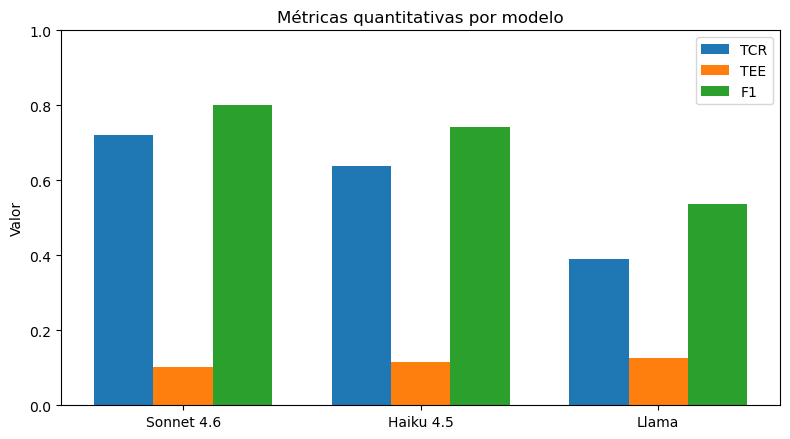

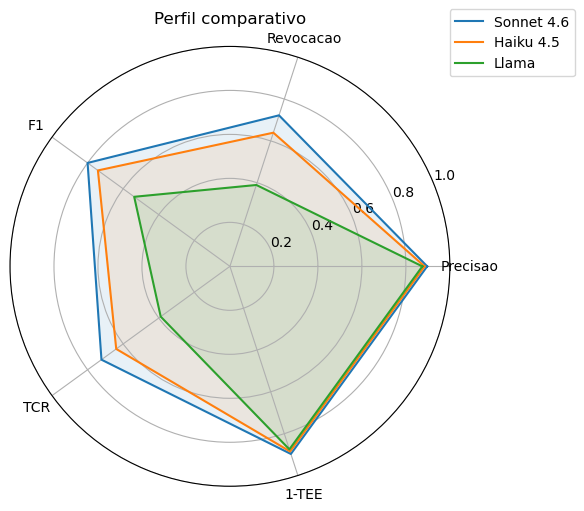

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# (a) Barras: TCR, TEE, F1
fig, ax = plt.subplots(figsize=(8, 4.5))
mets = ["TCR", "TEE", "F1"]
x = np.arange(len(MODELOS)); w = 0.25
for i, m in enumerate(mets):
    ax.bar(x + (i-1)*w, [tab1.loc[n, m] for n in MODELOS], w, label=m)
ax.set_xticks(x); ax.set_xticklabels(list(MODELOS)); ax.set_ylim(0, 1)
ax.set_ylabel("Valor"); ax.set_title("Métricas quantitativas por modelo")
ax.legend(); fig.tight_layout(); fig.savefig("figuras/grafico_metricas.png", dpi=150)
plt.show()

# (b) Radar: P, R, F1, TCR, (1-TEE)
labels = ["Precisao", "Revocacao", "F1", "TCR", "1-TEE"]
ang = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist(); ang += ang[:1]
fig2 = plt.figure(figsize=(6, 6)); axr = plt.subplot(111, polar=True)
for n in MODELOS:
    vals = [tab1.loc[n, "Precisao"], tab1.loc[n, "Revocacao"], tab1.loc[n, "F1"],
            tab1.loc[n, "TCR"], 1 - tab1.loc[n, "TEE"]]
    vals += vals[:1]
    axr.plot(ang, vals, label=n); axr.fill(ang, vals, alpha=0.1)
axr.set_xticks(ang[:-1]); axr.set_xticklabels(labels); axr.set_ylim(0, 1)
axr.set_title("Perfil comparativo"); axr.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
fig2.tight_layout(); fig2.savefig("figuras/grafico_radar.png", dpi=150)
plt.show()

## 13. Tabelas em Markdown (para colar no artigo)

In [ ]:
print("### Tabela 1 — Resultados quantitativos\n")
print(tab1.to_markdown())
print("\n\n### Tabela 2 — Omissões por categoria\n")
print(tab2.to_markdown())
# salva tambem em arquivo
Path("dados/tabelas_markdown.md").write_text(
    "### Tabela 1\n\n" + tab1.to_markdown() + "\n\n### Tabela 2\n\n" + tab2.to_markdown(),
    encoding="utf-8")
print("\nSalvo em dados/tabelas_markdown.md")

### Tabela 1 — Resultados quantitativos

| Modelo     |   identificados |   omitidos |   espurios |   TCR |   TRO |   TEE |   Precisao |   Revocacao |    F1 |
|:-----------|----------------:|-----------:|-----------:|------:|------:|------:|-----------:|------------:|------:|
| Sonnet 4.6 |              26 |         10 |          3 | 0.722 | 0.278 | 0.103 |      0.897 |       0.722 | 0.8   |
| Haiku 4.5  |              23 |         13 |          3 | 0.639 | 0.361 | 0.115 |      0.885 |       0.639 | 0.742 |
| Llama      |              14 |         22 |          2 | 0.389 | 0.611 | 0.125 |      0.875 |       0.389 | 0.538 |


### Tabela 2 — Omissões por categoria

| Modelo (omissoes)   |   ator |   atividade |   fluxo_excecao |   requisito |   implicito |
|:--------------------|-------:|------------:|----------------:|------------:|------------:|
| Sonnet 4.6          |      0 |           0 |               0 |           7 |           3 |
| Haiku 4.5           |      1 |           1 |   

## 14. Avaliação qualitativa (Likert 1–5)

Preencha manualmente após inspecionar cada modelo gerado (Seção 8). As dimensões seguem o Apêndice E do artigo.
Edite o dicionário abaixo com as notas dos avaliadores e gere a Tabela 3.

In [ ]:
dimensoes = ["Fidelidade Semantica", "Cobertura de Atores", "Cobertura de Fluxos de Excecao",
             "Estrutura e Coerencia", "Utilidade Pratica"]
# Exemplo (substitua pelos valores reais dos avaliadores):
notas_qualitativas = {
    "Sonnet 4.6": {d: None for d in dimensoes},
    "Haiku 4.5":  {d: None for d in dimensoes},
    "Llama":      {d: None for d in dimensoes},
}
tab3 = pd.DataFrame(notas_qualitativas).T
tab3.index.name = "Modelo"
tab3

,Fidelidade Semantica,Cobertura de Atores,Cobertura de Fluxos de Excecao,Estrutura e Coerencia,Utilidade Pratica
Modelo,,,,,
Sonnet 4.6,None,None,None,None,None
Haiku 4.5,None,None,None,None,None
Llama,None,None,None,None,None






---
**Reprodutibilidade:** as saídas brutas das LLMs estão em dados/saidas/*.md, as avaliações do juiz em
dados/saidas/aval_*.json, as tabelas em dados/*.csv` e as figuras em figuras/*.png. Apague o cache para
reexecutar do zero.